# 🔍 Notebook 1 — Exploratory Data Analysis (EDA)

**Project:** Financial Fraud Detection System 
**Author:** Pedro Paniagua Goitia | GitHub: @kmax 

## What this notebook does
- Loads and inspects the raw transactions dataset
- Analyses missing values and data quality
- Explores the fraud rate and its distribution across key variables
- Produces publication-ready visualisations

**Input:** `data/raw/transactions.csv` 
**Output:** cleaned insights + figures saved to `reports/figures/`

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':130, 'font.size':11, 'axes.titlesize':13})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Inspect

In [16]:
df = pd.read_csv('../data/raw/transactions.csv')
print(f'Shape: {df.shape}')
print(f'\nDtypes:\n{df.dtypes}')
df.head()

Shape: (50000, 8)

Dtypes:
transaction_id               str
amount                   float64
hour                       int64
country                      str
channel                      str
transactions_last_24h      int64
days_as_customer           int64
is_fraud                   int64
dtype: object


,transaction_id,amount,hour,country,channel,transactions_last_24h,days_as_customer,is_fraud
0,TXN0000000,7.34,11,US,pos,4,133,0
1,TXN0000001,80.47,22,NaN,pos,3,7,0
2,TXN0000002,649.33,17,Spain,online,0,165,0
3,TXN0000003,151.30,15,US,pos,4,578,0
4,TXN0000004,232.45,7,Germany,atm,3,288,0


In [17]:
# ── Missing values audit ────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
audit = audit[audit['Missing'] > 0]
print('Missing values audit:')
print(audit)
print(f'\nFraud rate: {df.is_fraud.mean()*100:.2f}%')
print(f'Total fraudulent transactions: {df.is_fraud.sum():,}')

Missing values audit:
         Missing  Pct (%)
amount       300      0.6
country      800      1.6

Fraud rate: 4.32%
Total fraudulent transactions: 2,158


## 2. Target Distribution — Class Imbalance

> **Key insight:** Only ~4% of transactions are fraudulent. This is a classic imbalanced classification problem — standard accuracy is misleading here. We will use AUC-ROC and Precision-Recall as primary metrics.

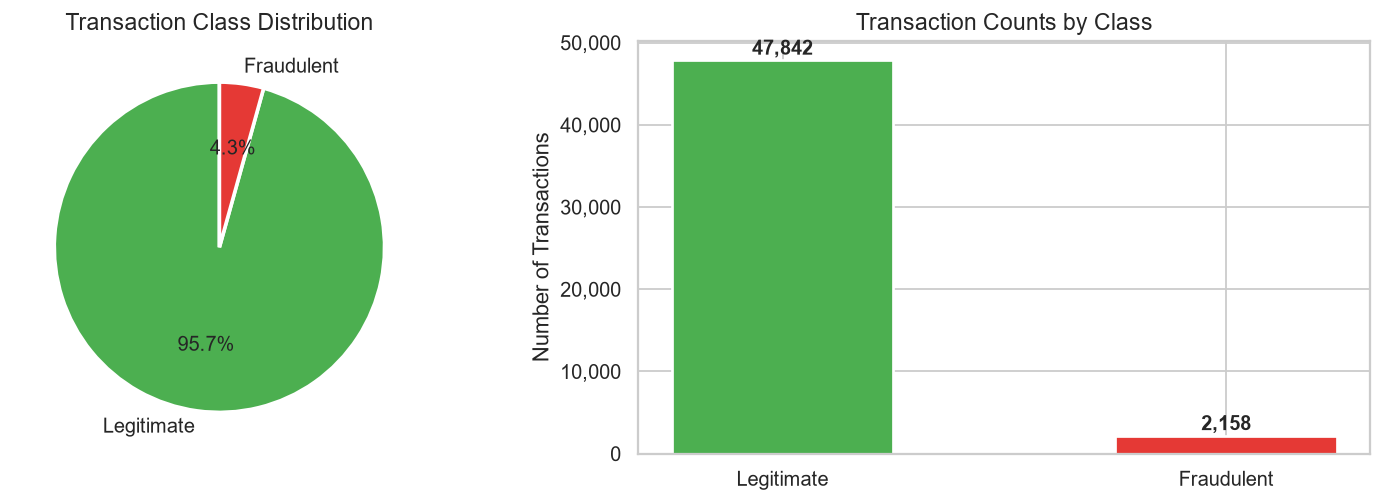

Figure saved ✓


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ['Legitimate', 'Fraudulent']
sizes  = df['is_fraud'].value_counts().values
colors = ['#4CAF50', '#E53935']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Transaction Class Distribution')

# Bar chart with counts
counts = df['is_fraud'].value_counts()
bars = axes[1].bar(['Legitimate','Fraudulent'], counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, count in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Transaction Counts by Class')
axes[1].set_ylabel('Number of Transactions')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,p: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved ✓')

## 3. Fraud by Hour of Day

> **Key insight:** Fraud spikes sharply between 11PM and 3AM — fraudsters exploit reduced monitoring during off-hours.

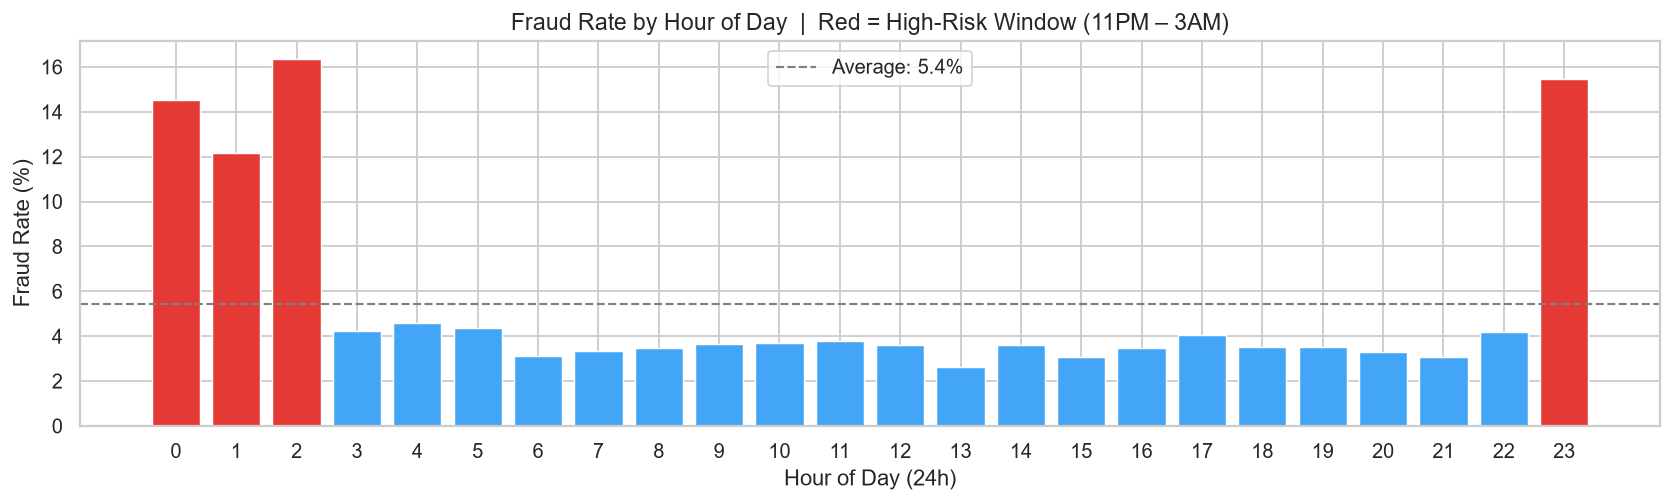

In [19]:
fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(fraud_by_hour.index, fraud_by_hour.values,
              color=['#E53935' if (h>=23 or h<=2) else '#42A5F5' for h in fraud_by_hour.index],
              edgecolor='white', linewidth=0.8)
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Hour of Day  |  Red = High-Risk Window (11PM – 3AM)')
ax.set_xticks(range(24))
ax.axhline(fraud_by_hour.mean(), color='grey', linestyle='--', linewidth=1.2, label=f'Average: {fraud_by_hour.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/02_fraud_by_hour.png', bbox_inches='tight')
plt.show()

## 4. Fraud by Country and Channel

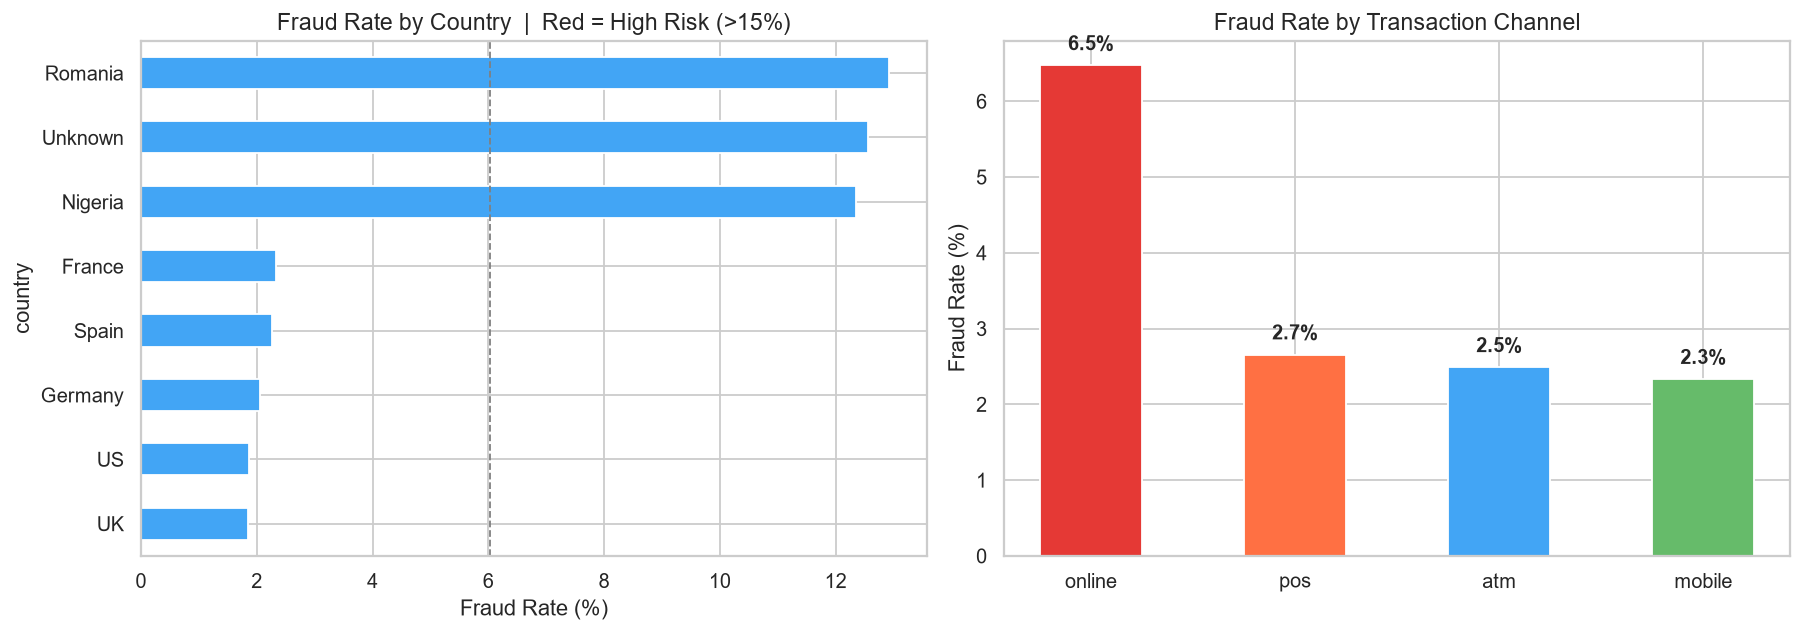

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By country
fraud_country = (df.groupby('country')['is_fraud'].mean()*100).sort_values(ascending=True)
colors_country = ['#E53935' if v > 15 else '#42A5F5' for v in fraud_country.values]
fraud_country.plot(kind='barh', ax=axes[0], color=colors_country, edgecolor='white')
axes[0].set_title('Fraud Rate by Country  |  Red = High Risk (>15%)')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].axvline(fraud_country.mean(), color='grey', linestyle='--', linewidth=1)

# By channel
fraud_channel = (df.groupby('channel')['is_fraud'].mean()*100).sort_values(ascending=False)
bars2 = axes[1].bar(fraud_channel.index, fraud_channel.values,
                    color=['#E53935','#FF7043','#42A5F5','#66BB6A'], width=0.5, edgecolor='white')
for bar, val in zip(bars2, fraud_channel.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Fraud Rate by Transaction Channel')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../reports/figures/03_fraud_by_country_channel.png', bbox_inches='tight')
plt.show()

## 5. Amount Distribution — Fraud vs Legitimate

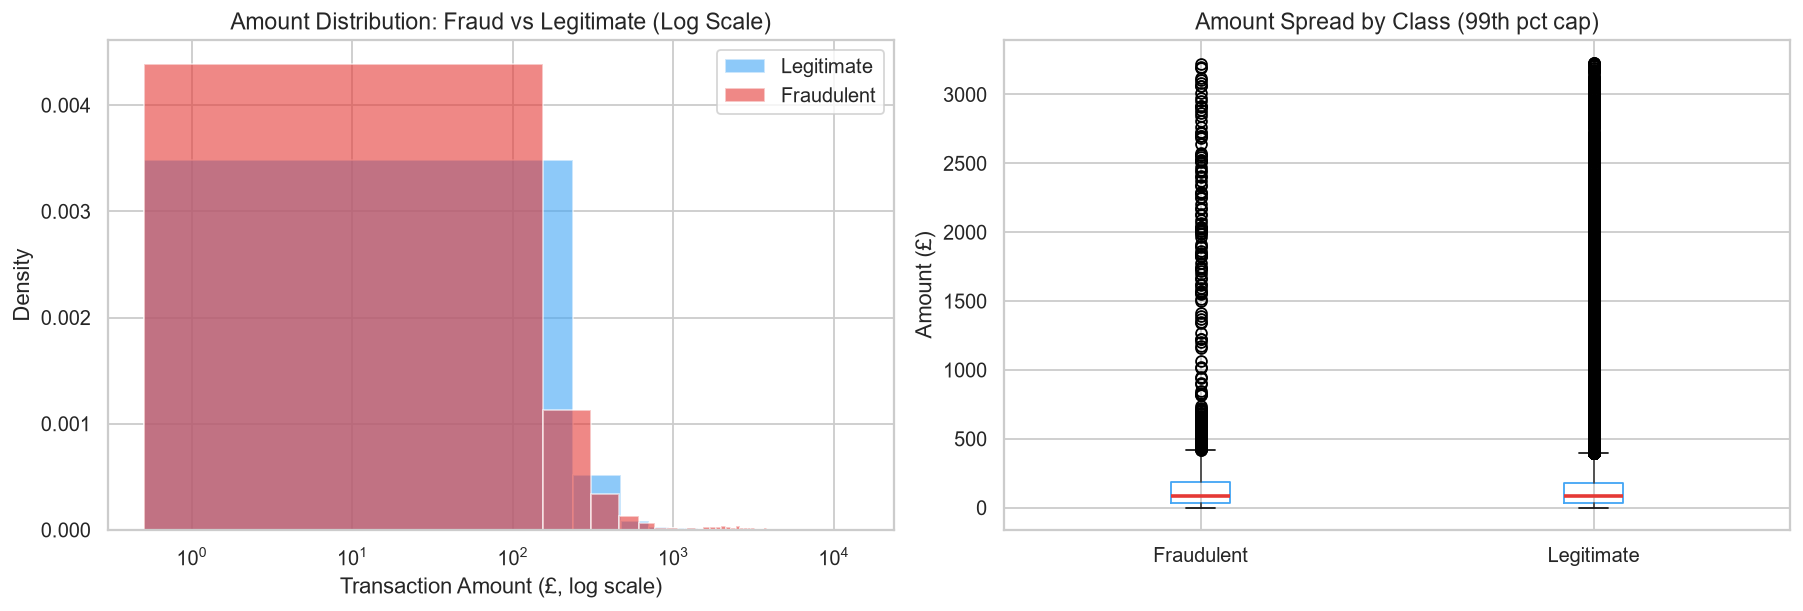


--- EDA Complete ---
Key findings:
  • Fraud rate: 4.3%
  • Avg fraudulent txn: £91
  • Avg legitimate txn: £90
  • Highest fraud country: Romania (13%)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale distribution
for label, color, val in [('Legitimate','#42A5F5',0),('Fraudulent','#E53935',1)]:
    subset = df[df['is_fraud']==val]['amount'].dropna()
    axes[0].hist(subset, bins=60, alpha=0.6, label=label, color=color, density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Transaction Amount (£, log scale)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution: Fraud vs Legitimate (Log Scale)')
axes[0].legend()

# Box plot
df_plot = df[df['amount'] < df['amount'].quantile(0.99)].copy()
df_plot['label'] = df_plot['is_fraud'].map({0:'Legitimate',1:'Fraudulent'})
df_plot.boxplot(column='amount', by='label', ax=axes[1],
                boxprops=dict(color='#42A5F5'),
                medianprops=dict(color='#E53935', linewidth=2))
axes[1].set_title('Amount Spread by Class (99th pct cap)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount (£)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/04_amount_distribution.png', bbox_inches='tight')
plt.show()
print('\n--- EDA Complete ---')
print('Key findings:')
print(f'  • Fraud rate: {df.is_fraud.mean()*100:.1f}%')
print(f'  • Avg fraudulent txn: £{df[df.is_fraud==1].amount.median():.0f}')
print(f'  • Avg legitimate txn: £{df[df.is_fraud==0].amount.median():.0f}')
print(f'  • Highest fraud country: {fraud_country.idxmax()} ({fraud_country.max():.0f}%)')